<a href="https://colab.research.google.com/github/PatrikBaldon/Statistical_Forecast/blob/main/Chronos_VS_IBP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Sales Forecasting & Data Cleaning Framework - SAP IBP Ecosystem (Ver. 2511)

**Obiettivo Professionale:**
Ottimizzazione del forecasting per il Material Group **HHCMFA** mediante
integrazione di AWS Chronos (univariato e multivariato) e metodologie
avanzate di data preparation. Il framework valuta e compara l'accuratezza
previsionale (WMAPE) su dati depurati da rumore statistico e bias di
pre-lancio, a livello di Statistical Family.

**Struttura Modulare:**
1. Configurazione & Costanti
2. Caricamento Dati (Ingestion Layer)
3. Preprocessing: Lifecycle Cleaning
4. Preprocessing: Outlier Detection & Correction
5. [ESTENSIBILE] Preprocessing aggiuntivi (es. smoothing, calendar effects)
6. Feature Engineering & Merge Driver Esterni
7. [ESTENSIBILE] Aggiunta di serie di correlazione esterne
8. Split Train / Future
9. AWS Chronos Forecasting (Univariato & Multivariato)
10. SAP IBP Forecast Retrieval
11. Consolidamento & Valutazione (WMAPE)
12. Visualizzazione

In [18]:
%%capture
!pip install chronos-forecasting pandas numpy matplotlib seaborn scikit-learn openpyxl statsmodels -q

In [19]:
import warnings
import logging

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import median_abs_deviation
from chronos import BaseChronosPipeline

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
log = logging.getLogger(__name__)
sns.set_theme(style="whitegrid", palette="muted")

In [20]:
class Config:
  """
  Centralizza tutti i parametri configurabili del framework.
  Modificare solo questa classe per adattare il pipeline a nuovi dataset
  o finestre temporali.
  """
  # Percorsi Input
  BASE_PATH: str = "/content/drive/MyDrive/DeLonghi_Dataset/"
  PATH_STAT_FAM: str = BASE_PATH + "Stat_Fam.xlsx"
  PATH_MAPPING: str = BASE_PATH + "mapping.xlsx"
  PATH_DRIVERS: str = BASE_PATH + "IBP_Glocal_External_Drivers_Optimized.csv"
  # Percorsi Output
  OUTPUT_PLOT: str = "comparativa_forecast_delonghi.png"
  OUTPUT_RESULTS: str = "accuracy_results.csv"
  # Filtro Material Group di interesse
  MATERIAL_GROUP: str = "HHCMFA"
  # Numero minimo di punti nei dataset
  MIN_TRAIN_POINTS: int = 5
  # Date di cutoff e orizzonte previsionale
  TRAIN_END_DATE: str = "2023-12-31"
  FORECAST_END_DATE: str = "2025-12-31"
  PREDICTION_LENGTH: int = 24
  # Parametri Outlier Detection
  OUTLIER_THRESHOLD: float = 3.0
  MIN_PERIODS_FOR_DECOMP: int = 24 # min periodi richiesti per STL
  # Modello Chronos
  CHRONOS_MODEL: str = "amazon/chronos-2"
  CHRONOS_DEVICE: str = "cpu" # oppure "cuda" se disponibile GPU
  # Colonne Covarianti (driver esterni)
  COVARIATE_COLS: list = [
  "US_CPI",
  "SP500_Consumer_Disc",
  "Coffee_Price",
  "DeLonghi",
  "US_Interest_Rate_Lag2",
  ]

  # ── Estensione: aggiungere qui ulteriori colonne di correlazione ──────────
  # EXTRA_COVARIATE_COLS: list = ["IBP_KF_Custom_Index_1", ...]
  # ─────────────────────────────────────────────────────────────────────────
  # Colonne identificative (granularità)

  ID_COLS: list = ["Statistical Family", "Submarket ID"]
  TS_ID_COL: str = "ts_id"
  DATE_COL: str = "Date"
  TARGET_RAW: str = "Actuals"
  TARGET_CLEAN: str = "Actuals_Cleaned"

## CARICAMENTO DATI (Ingestion Layer)

In [21]:
def load_and_melt_ibp_excel(filepath: str, sheet_name: str, value_col_name: str) -> pd.DataFrame:
  """
  Carica un foglio Excel in formato wide (colonne = mesi IBP 'Jan-23')
  e restituisce un DataFrame in formato long.
  Args:
  filepath: Percorso del file Excel.
  sheet_name: Nome del foglio da leggere.
  value_col_name: Nome da assegnare alla colonna dei valori.
  Returns:
  DataFrame con colonne: Statistical Family, Submarket ID, Date, <value_col_name>.
  """
  df = pd.read_excel(filepath, sheet_name=sheet_name)
  date_cols = [c for c in df.columns if "-" in str(c)]
  id_vars = Config.ID_COLS
  melted = df.melt(id_vars=id_vars, value_vars=date_cols,
  var_name=Config.DATE_COL, value_name=value_col_name)
  melted[Config.DATE_COL] = pd.to_datetime(melted[Config.DATE_COL], format="%b-%y")
  melted[value_col_name] = (
    pd.to_numeric(
      melted[value_col_name].astype(str).str.replace(",", ""),
      errors="coerce"
    ).fillna(0)
  )
  return melted

def load_all_data(cfg: Config) -> dict:
  """
  Esegue l'ingestion completa di tutti i sorgenti dati.
  Returns:
    Dizionario con chiavi: actuals, fcst_24m, mapping, drivers.
  """
  log.info("Caricamento dati in corso...")
  from google.colab import drive # noqa — rimuovere se non si usa Colab
  drive.mount("/content/drive")
  actuals = load_and_melt_ibp_excel(cfg.PATH_STAT_FAM, "actuals_new", cfg.TARGET_RAW)
  fcst_24m = load_and_melt_ibp_excel(cfg.PATH_STAT_FAM, "fcst_24MGB", "SAP_Fcst_24M")
  mapping = pd.read_excel(cfg.PATH_MAPPING, sheet_name="mapping")
  drivers = pd.read_csv(cfg.PATH_DRIVERS)
  drivers["PERIODID"] = pd.to_datetime(drivers["PERIODID"])
  drivers.rename(columns={"PERIODID": cfg.DATE_COL}, inplace=True)
  log.info(f" Actuals: {actuals.shape[0]:,} righe")
  log.info(f" Forecast: {fcst_24m.shape[0]:,} righe")
  log.info(f" Drivers: {drivers.shape[0]:,} righe")
  return dict(actuals=actuals, fcst_24m=fcst_24m, mapping=mapping, drivers=drivers)

def clean_lifecycle(group: pd.DataFrame, target_col: str = Config.TARGET_RAW) -> pd.DataFrame:
  """
  Imposta NaN prima della prima vendita (pre-lancio) e 0 dopo l'ultima
  (post-fine ciclo di vita). Garantisce che il modello apprenda solo
  dall'effettiva finestra di mercato del prodotto.

  Args:
    group: Sottoinsieme del DataFrame per una singola serie temporale.
    target_col: Colonna target da pulire.

  Returns:
    DataFrame con i valori di target_col corretti.
  """
  group = group.sort_values(Config.DATE_COL)
  active = group[target_col] > 0
  if not active.any():
    return group
  first_idx = group[active].index[0]
  last_idx = group[active].index[-1]
  group.loc[group.index < first_idx, target_col] = np.nan
  group.loc[group.index > last_idx, target_col] = 0
  return group


## PREPROCESSING — OUTLIER DETECTION & CORRECTION (STL-based)

In [22]:
def detect_and_correct_outliers(
  group: pd.DataFrame,
  target_col: str = Config.TARGET_RAW,
  out_col: str = Config.TARGET_CLEAN,
  threshold: float = Config.OUTLIER_THRESHOLD,
  min_periods: int = Config.MIN_PERIODS_FOR_DECOMP,
) -> pd.DataFrame:
  """
  Identifica e corregge outlier tramite decomposizione STL additiva.
  La correzione sostituisce il valore anomalo con Trend + Stagionalità,
  preservando il segnale senza distorcere la componente ciclica.
  Richiede almeno `min_periods` osservazioni non-NaN per effettuare
  la decomposizione; in caso contrario esegue un fallback diretto.
  Args:
    group: Serie temporale di un singolo ts_id.
    target_col: Colonna con i valori originali.
    out_col: Colonna di output con i valori corretti.
    threshold: Moltiplicatore MAD per la soglia di outlier detection.
    min_periods: Numero minimo di periodi per la STL decomposition.
  Returns:
    DataFrame con la colonna `out_col` aggiunta.
"""
  valid = group.dropna(subset=[target_col])
  group[out_col] = group[target_col]
  if len(valid) < min_periods:
    return group
  series = group.set_index(Config.DATE_COL)[target_col].fillna(0)
  try:
    decomp = seasonal_decompose(series, model="additive", period=12,
    extrapolate_trend="freq")
    residuals = decomp.resid
    mad = median_abs_deviation(residuals, nan_policy="omit")
    med = np.nanmedian(residuals)
    outlier_mask = np.abs(residuals - med) > (threshold * mad)
    corrected = (decomp.trend + decomp.seasonal).clip(lower=0)
    cleaned = series.copy()
    cleaned[outlier_mask] = corrected[outlier_mask]
    cleaned[group.set_index(Config.DATE_COL)[target_col].isna()] = np.nan
    group[out_col] = cleaned.values
  except Exception as exc:
    log.debug(f"Decomposizione fallita per gruppo ({exc}), fallback su originali.")
  return group

## STEP AGGIUNTIVI DI PREPROCESSING

In [23]:
EXTRA_PREPROCESSING_STEPS = []
def run_preprocessing_pipeline(actuals_df: pd.DataFrame) -> pd.DataFrame:
  """
  Esegue l'intera pipeline di preprocessing sugli actuals:
    1. Lifecycle cleaning
    2. Outlier detection & correction
    3. Step aggiuntivi (EXTRA_PREPROCESSING_STEPS)
  Args:
    actuals_df: DataFrame in formato long con colonna TARGET_RAW.
  Returns:
    DataFrame arricchito con colonna TARGET_CLEAN e opzionali.
  """
  log.info("Avvio pipeline preprocessing...")
  df = (
    actuals_df
    .groupby(Config.ID_COLS, group_keys=False)
    .apply(clean_lifecycle)
  )
  log.info(" ✓ Lifecycle cleaning completato.")
  df = (
    df
    .groupby(Config.ID_COLS, group_keys=False)
    .apply(detect_and_correct_outliers)
  )
  log.info(" ✓ Outlier correction (STL) completata.")
  for step_fn in EXTRA_PREPROCESSING_STEPS:
    fn_name = getattr(step_fn, "__name__", str(step_fn))
    df = df.groupby(Config.ID_COLS, group_keys=False).apply(step_fn)
    log.info(f" ✓ Step custom '{fn_name}' completato.")
  return df.reset_index(drop=True)

## FEATURE ENGINEERING & MERGE DRIVER ESTERNI

In [24]:
def build_master_dataframe(
  actuals_df: pd.DataFrame,
  mapping_df: pd.DataFrame,
  drivers_df: pd.DataFrame,
  cfg: Config,
  ) -> pd.DataFrame:

  """
  Costruisce il master DataFrame filtrando per MATERIAL_GROUP,
  unendo il mapping, i driver esterni e aggiungendo la colonna ts_id.
  I driver vengono proiettati su tutto l'orizzonte temporale tramite
  forward-fill + back-fill per gestire eventuali gap di disponibilità.
  Args:
    actuals_df: Actuals preprocessati.
    mapping_df: Tabella di mapping Statistical Family → Material Group / Market.
    drivers_df: Driver macroeconomici e di mercato.
    cfg: Configurazione.
  Returns:
    master_df pronto per lo split train/future.
  """
  map_cols = cfg.ID_COLS + ["Material Group", "Market"]
  map_sub = mapping_df[map_cols].drop_duplicates()
  merged = pd.merge(actuals_df, map_sub, on=cfg.ID_COLS, how="inner")
  filtered = merged[merged["Material Group"] == cfg.MATERIAL_GROUP].copy()
  if filtered.empty:
    raise ValueError(f"Nessun dato trovato per Material Group '{cfg.MATERIAL_GROUP}'.")
  master = pd.merge(filtered, drivers_df, on=cfg.ID_COLS + [cfg.DATE_COL], how="left")
  # Forward/Back-fill dei driver per evitare NaN durante il forecasting
  master[cfg.COVARIATE_COLS] = (
    master
    .groupby(cfg.ID_COLS)[cfg.COVARIATE_COLS]
    .transform(lambda s: s.ffill().bfill())
  )
  master[cfg.TS_ID_COL] = (
    master["Statistical Family"].astype(str)
    + "_"
    + master["Submarket ID"].astype(str)
  )
  log.info(f"Master DataFrame: {master.shape[0]:,} righe | "
  f"{master[cfg.TS_ID_COL].nunique()} serie temporali")
  return master

## [ESTENSIBILE] SERIE DI CORRELAZIONE ESTERNE

In [25]:
# Per aggiungere nuovi driver/serie di correlazione al master DataFrame,
# creare una funzione con firma:
# fn(master_df: pd.DataFrame, cfg: Config) -> pd.DataFrame
# e aggiungere una chiamata nel blocco di orchestrazione principale.
#
# Esempio:
# def add_social_media_trend(master_df, cfg):
# social = pd.read_csv("social_trend.csv")
# social["Date"] = pd.to_datetime(social["Date"])
# master_df = pd.merge(master_df, social, on=["Date"], how="left")
# cfg.COVARIATE_COLS.append("Social_Trend_Index")
# return master_df

## SPLIT TRAIN / FUTURE

In [26]:
def build_aligned_split(master_df: pd.DataFrame, cfg: Config) -> tuple[pd.DataFrame, pd.DataFrame]:

    train_raw  = master_df[master_df[cfg.DATE_COL] <= cfg.TRAIN_END_DATE].copy()
    future_raw = master_df[
        (master_df[cfg.DATE_COL] > cfg.TRAIN_END_DATE) &
        (master_df[cfg.DATE_COL] <= cfg.FORECAST_END_DATE)
    ].copy()

    # 1. Serie con abbastanza punti validi nel training
    train_valid_counts = (
        train_raw
        .dropna(subset=[cfg.TARGET_RAW])
        .groupby(cfg.TS_ID_COL)[cfg.DATE_COL]
        .count()
    )
    ids_train = set(
        train_valid_counts[train_valid_counts >= cfg.MIN_TRAIN_POINTS].index
    )

    # 2. Serie presenti anche nel futuro
    ids_future = set(future_raw[cfg.TS_ID_COL].unique())

    # 3. Intersezione finale
    valid_ids = ids_train & ids_future

    if not valid_ids:
        raise ValueError(
            "Nessuna serie temporale valida. "
            "Verificare TRAIN_END_DATE, FORECAST_END_DATE e MIN_TRAIN_POINTS."
        )

    excluded = (ids_train | ids_future) - valid_ids
    log.info(f"Serie valide: {len(valid_ids)} | Escluse (dati insufficienti): {len(excluded)}")
    if excluded:
        log.warning(f"Serie escluse: {sorted(excluded)}")

    # 4. Applicazione del filtro ← questo era il pezzo mancante
    train_df  = train_raw[train_raw[cfg.TS_ID_COL].isin(valid_ids)].copy()
    future_df = future_raw[future_raw[cfg.TS_ID_COL].isin(valid_ids)].copy()
    future_df = _pad_future_to_prediction_length(future_df, valid_ids, cfg)

    return train_df, future_df


def _pad_future_to_prediction_length(
  future_df: pd.DataFrame,
  valid_ids: set,
  cfg: Config,
  ) -> pd.DataFrame:
  """
  Assicura che ogni ts_id in future_df abbia esattamente `PREDICTION_LENGTH`
  periodi mensili consecutivi a partire dal primo mese successivo a
  TRAIN_END_DATE. Periodi mancanti vengono aggiunti con covarianti NaN
  (Chronos gestisce i gap tramite interpolazione interna).
  """
  start = pd.Timestamp(cfg.TRAIN_END_DATE) + pd.offsets.MonthBegin(1)
  full_dates = pd.date_range(start=start, periods=cfg.PREDICTION_LENGTH, freq="MS")
  records = []
  for ts_id in valid_ids:
    stat_fam, subm_id = ts_id.rsplit("_", 1)
    for d in full_dates:
      records.append({
        cfg.TS_ID_COL: ts_id,
        cfg.DATE_COL: d,
        "Statistical Family": stat_fam,
        "Submarket ID": subm_id,
     })
  skeleton = pd.DataFrame(records)
  padded = pd.merge(
    skeleton,
    future_df.drop(columns=["Statistical Family", "Submarket ID"], errors="ignore"),
    on=[cfg.TS_ID_COL, cfg.DATE_COL],
    how="left",
  )
  # Forward-fill covarianti nel skeleton
  padded[cfg.COVARIATE_COLS] = (
    padded
    .groupby(cfg.TS_ID_COL)[cfg.COVARIATE_COLS]
    .transform(lambda s: s.ffill().bfill())
  )
  return padded

## AWS CHRONOS FORECASTING

In [27]:
def load_chronos_pipeline(cfg: Config) -> BaseChronosPipeline:
  """Carica il modello Chronos con i parametri di configurazione."""
  log.info(f"Caricamento Chronos '{cfg.CHRONOS_MODEL}' su {cfg.CHRONOS_DEVICE}...")
  return BaseChronosPipeline.from_pretrained(
  cfg.CHRONOS_MODEL, device_map=cfg.CHRONOS_DEVICE
  )

def run_chronos_forecast(
  pipeline: BaseChronosPipeline,
  train_df: pd.DataFrame,
  future_df: pd.DataFrame,
  target_col: str,
  use_covariates: bool,
  cfg: Config,
  label: str = "",
  ) -> pd.DataFrame:
  """
  Esegue il forecasting Chronos su una singola combinazione
  (target_col × modalità univariata/multivariata).
  Il futuro viene filtrato ai soli ts_id presenti in train_df prima della
  chiamata a predict_df, eliminando definitivamente il mismatch di ID.
  Args:
    pipeline: Pipeline Chronos pre-caricata.
    train_df: Dati di training.
    future_df: Finestra futura (già allineata).
    target_col: Colonna target ('Actuals' o 'Actuals_Cleaned').
    use_covariates: Se True, include COVARIATE_COLS nella chiamata.
    cfg: Configurazione.
    label: Suffisso per la colonna di output (es. 'Multi_Clean').
  Returns:
    DataFrame con colonne ts_id, Date, <forecast_col>.
    """
  cov_cols = cfg.COVARIATE_COLS if use_covariates else []
  required_train = [cfg.TS_ID_COL, cfg.DATE_COL, target_col] + cov_cols
  required_future = [cfg.TS_ID_COL, cfg.DATE_COL] + cov_cols
  ctx = train_df[required_train].dropna(subset=[target_col]).copy()
  fut = future_df[required_future].copy()
  # Allineamento rigoroso degli ID
  common_ids = set(ctx[cfg.TS_ID_COL].unique()) & set(fut[cfg.TS_ID_COL].unique())
  ctx = ctx[ctx[cfg.TS_ID_COL].isin(common_ids)]
  fut = fut[fut[cfg.TS_ID_COL].isin(common_ids)]
  # Mantieni esattamente PREDICTION_LENGTH periodi per ts_id in future
  fut = (
    fut
    .sort_values([cfg.TS_ID_COL, cfg.DATE_COL])
    .groupby(cfg.TS_ID_COL)
    .head(cfg.PREDICTION_LENGTH)
  )
  log.info(f" Chronos [{label}] → {len(common_ids)} serie | "
  f"covarianti: {'Sì' if use_covariates else 'No'} | "
  f"target: {target_col}")
  forecast_col = f"AWS_{label}"
  pred = pipeline.predict_df(
    ctx,
    future_df=fut,
    prediction_length=cfg.PREDICTION_LENGTH,
    quantile_levels=[0.5],
    cross_learning=True,
    id_column=cfg.TS_ID_COL,
    timestamp_column=cfg.DATE_COL,
    target=target_col,
  )
  pred.rename(columns={"0.5": forecast_col}, inplace=True)
  log.info(f" ✓ Forecast [{label}] completato: {pred.shape[0]:,} righe")
  return pred[[cfg.TS_ID_COL, cfg.DATE_COL, forecast_col]]

## SAP IBP FORECAST RETRIEVAL

In [28]:
def prepare_sap_forecast(
  fcst_24m_df: pd.DataFrame,
  cfg: Config,
  ) -> pd.DataFrame:
  """
  Prepara il forecast SAP IBP per la finestra di valutazione.
  Aggiunge ts_id e filtra al periodo (TRAIN_END_DATE, FORECAST_END_DATE].
  """
  sap = fcst_24m_df.copy()
  sap[cfg.TS_ID_COL] = (
    sap["Statistical Family"].astype(str) + "_" + sap["Submarket ID"].astype(str)
  )
  sap_filtered = sap[
    (sap[cfg.DATE_COL] > cfg.TRAIN_END_DATE) &
    (sap[cfg.DATE_COL] <= cfg.FORECAST_END_DATE)
  ][[cfg.TS_ID_COL, cfg.DATE_COL, "SAP_Fcst_24M"]].copy()
  log.info(f"SAP IBP Forecast: {sap_filtered.shape[0]:,} righe in finestra di valutazione")
  return sap_filtered

## CONSOLIDAMENTO & VALUTAZIONE (WMAPE)

In [29]:
def wmape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
  """
  Weighted Mean Absolute Percentage Error.
  Il peso è proporzionale al volume degli actuals, rendendo la metrica
  robusta alle serie a basso volume.
  """
  denom = np.nansum(y_true)
  return (np.nansum(np.abs(y_true - y_pred)) / denom * 100) if denom > 0 else np.nan

def build_evaluation_dataframe(
  future_df: pd.DataFrame,
  sap_fcst: pd.DataFrame,
  forecasts: dict,
  cfg: Config,
  ) -> pd.DataFrame:
  """
  Unisce actuals, SAP forecast e tutti i forecast AWS in un unico DataFrame.
  Utilizza inner join per garantire che la valutazione sia effettuata solo
  sulle serie e date coperte da tutti i modelli.
  Args:
    future_df: Finestra futura con actuals reali (ove disponibili).
    sap_fcst: Forecast SAP IBP.
    forecasts: Dict {label: forecast_df} per ogni variante Chronos.
    cfg: Configurazione.
  Returns:
    eval_df con tutte le colonne di forecast allineate.
  """
  eval_df = future_df[[
    cfg.TS_ID_COL, cfg.DATE_COL,
    cfg.TARGET_RAW, cfg.TARGET_CLEAN,
    "Statistical Family",
  ]].copy()
  eval_df = pd.merge(eval_df, sap_fcst, on=[cfg.TS_ID_COL, cfg.DATE_COL], how="inner")
  for label, fcst_df in forecasts.items():
    fcst_col = f"AWS_{label}"
    eval_df = pd.merge(eval_df, fcst_df, on=[cfg.TS_ID_COL, cfg.DATE_COL], how="inner")
  log.info(f"Eval DataFrame consolidato: {eval_df.shape[0]:,} righe | "
  f"{eval_df[cfg.TS_ID_COL].nunique()} serie")
  return eval_df

def compute_accuracy_metrics(eval_df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
  """
  Calcola WMAPE e Accuratezza (100 - WMAPE) per ogni Statistical Family
  e per ciascun modello, sia su Actuals originali che su Actuals Cleaned.
  Returns:
  DataFrame ordinato per volume decrescente con tutte le metriche.
  """
  metrics = []
  for fam in eval_df["Statistical Family"].unique():
    fam_df = eval_df[eval_df["Statistical Family"] == fam]
    row = {
    "Statistical Family": fam,
    "Vol_Actuals": fam_df[cfg.TARGET_RAW].sum(),
    "Vol_Cleaned": fam_df[cfg.TARGET_CLEAN].sum(),
    "Acc_SAP_Orig_%": max(0, 100 - wmape(fam_df[cfg.TARGET_RAW], fam_df["SAP_Fcst_24M"])),
    "Acc_AWS_Multi_Orig_%": max(0, 100 - wmape(fam_df[cfg.TARGET_RAW], fam_df.get("AWS_Multi_Orig", fam_df[cfg.TARGET_RAW]))),
    "Acc_AWS_Multi_Clean_%": max(0, 100 - wmape(fam_df[cfg.TARGET_CLEAN], fam_df.get("AWS_Multi_Clean", fam_df[cfg.TARGET_CLEAN]))),
    "Acc_AWS_Uni_Clean_%": max(0, 100 - wmape(fam_df[cfg.TARGET_CLEAN], fam_df.get("AWS_Uni_Clean", fam_df[cfg.TARGET_CLEAN]))),
    }
    metrics.append(row)
  results = (
    pd.DataFrame(metrics)
    .sort_values("Vol_Actuals", ascending=False)
    .reset_index(drop=True)
  )
  log.info("Metriche di accuratezza calcolate:")
  log.info("\n" + results.round(2).to_string(index=False))
  return results

## VISUALIZZAZIONE

In [30]:
def plot_global_comparison(eval_df: pd.DataFrame, cfg: Config) -> None:
  """
  Genera il plot comparativo globale aggregando per data tutte le serie
  temporali. Mostra Actuals (originali e cleaned) vs tutti i modelli.
  """
  trend = eval_df.groupby(cfg.DATE_COL).sum(numeric_only=True).reset_index()
  fig, ax = plt.subplots(figsize=(18, 8))
  ax.plot(trend[cfg.DATE_COL], trend[cfg.TARGET_RAW],
          label="Actuals Originali", color="gray", alpha=0.45, linestyle="--")
  ax.plot(trend[cfg.DATE_COL], trend[cfg.TARGET_CLEAN],
          label="Actuals Puliti (Benchmark)", color="black", linewidth=3, marker="o", markersize=4)
  ax.plot(trend[cfg.DATE_COL], trend["SAP_Fcst_24M"],
          label="SAP IBP Forecast", color="crimson", linewidth=2)
  if "AWS_Multi_Clean" in trend.columns:
    ax.plot(trend[cfg.DATE_COL], trend["AWS_Multi_Clean"],
            label="AWS Chronos Multi (Cleaned)", color="dodgerblue", linewidth=2.5)
  if "AWS_Uni_Clean" in trend.columns:
    ax.plot(trend[cfg.DATE_COL], trend["AWS_Uni_Clean"],
    label="AWS Chronos Uni (Cleaned)", color="forestgreen", linewidth=2, linestyle="-.")
  if "AWS_Multi_Orig" in trend.columns:
    ax.plot(trend[cfg.DATE_COL], trend["AWS_Multi_Orig"],
    label="AWS Chronos Multi (Orig)", color="darkorange", linewidth=2, linestyle=":")
  ax.set_title(
    f"Comparativa Forecast Globale {cfg.MATERIAL_GROUP}: "
    "Impatto della Pulizia Dati e Variabili Esogene",
    fontsize=15, fontweight="bold",
  )
  ax.set_xlabel("Data", fontsize=12)
  ax.set_ylabel("Volumi Aggregati", fontsize=12)
  ax.legend(fontsize=10, loc="upper left")
  ax.grid(True, which="both", linestyle=":", alpha=0.5)
  plt.tight_layout()
  plt.savefig(cfg.OUTPUT_PLOT, dpi=150)
  log.info(f"Plot salvato in '{cfg.OUTPUT_PLOT}'")
  plt.show()

# ORCHESTRAZIONE PRINCIPALE

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


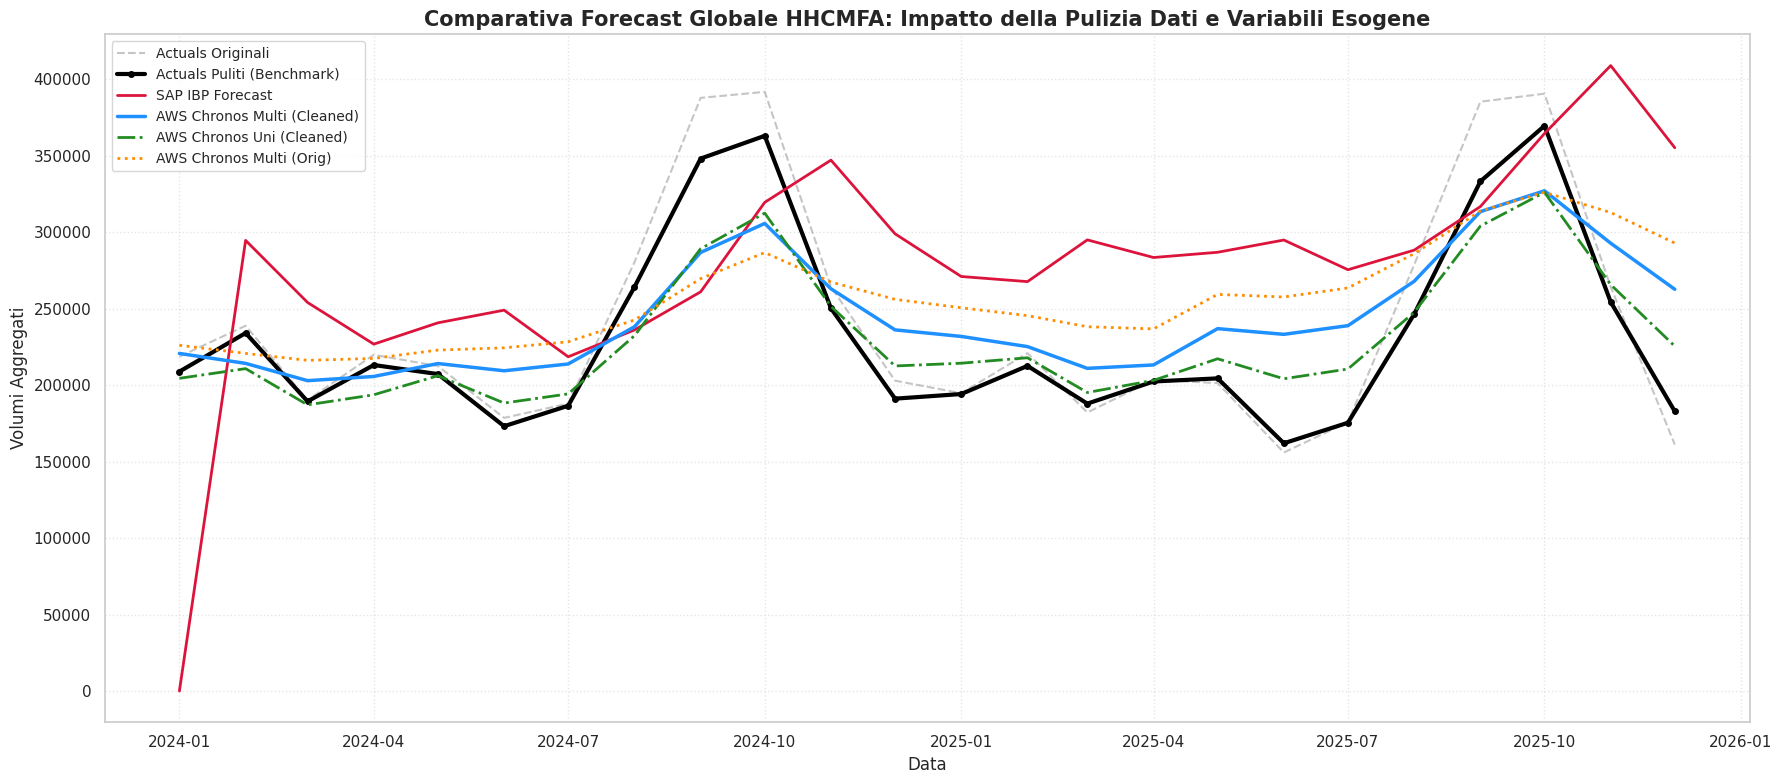

In [31]:
def main():
  cfg = Config()
  # ── 1. Ingestion ─────────────────────────────────────────────────────────
  data = load_all_data(cfg)
  # ── 2-5. Preprocessing Pipeline ──────────────────────────────────────────
  actuals_clean = run_preprocessing_pipeline(data["actuals"])
  # ── 6. Master DataFrame ───────────────────────────────────────────────────
  master_df = build_master_dataframe(
    actuals_clean, data["mapping"], data["drivers"], cfg
  )
  # ── 7. [Hook] Aggiungere qui serie di correlazione extra ─────────────────
  # master_df = add_social_media_trend(master_df, cfg)
  # ── 8. Split allineato ────────────────────────────────────────────────────
  train_df, future_df = build_aligned_split(master_df, cfg)
  # ── 9. Chronos Forecasting ────────────────────────────────────────────────
  pipeline = load_chronos_pipeline(cfg)
  forecasts = {}
  forecasts["Multi_Clean"] = run_chronos_forecast(
    pipeline, train_df, future_df,
    target_col=cfg.TARGET_CLEAN, use_covariates=True,
    cfg=cfg, label="Multi_Clean",
  )
  forecasts["Uni_Clean"] = run_chronos_forecast(
    pipeline, train_df, future_df,
    target_col=cfg.TARGET_CLEAN, use_covariates=False,
    cfg=cfg, label="Uni_Clean",
  )
  forecasts["Multi_Orig"] = run_chronos_forecast(
    pipeline, train_df, future_df,
    target_col=cfg.TARGET_RAW, use_covariates=True,
    cfg=cfg, label="Multi_Orig",
  )
  # ── 10. SAP IBP ───────────────────────────────────────────────────────────
  sap_fcst = prepare_sap_forecast(data["fcst_24m"], cfg)
  # ── 11. Consolidamento & Metriche ─────────────────────────────────────────
  eval_df = build_evaluation_dataframe(future_df, sap_fcst, forecasts, cfg)
  results = compute_accuracy_metrics(eval_df, cfg)
  results.to_csv(cfg.OUTPUT_RESULTS, index=False)
  log.info(f"Risultati salvati in '{cfg.OUTPUT_RESULTS}'")
  # ── 12. Visualizzazione ───────────────────────────────────────────────────
  plot_global_comparison(eval_df, cfg)
  return eval_df, results

if __name__ == "__main__":
  eval_df, results = main()